# Đánh giá mô hình BiLSTM (Confusion Matrix)

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
from torch.utils.data import DataLoader

# Thêm đường dẫn tới thư mục chứa source data_utils và models
sys.path.insert(0, os.path.abspath(r"D:\Study\HK6\CS221-NLP\CS221\Notebooks\Phase_3\2.DeepLearning"))
import data_utils
from models import BiLSTMAttention
from train import evaluate

In [2]:
# 1. Khai báo các đường dẫn cần thiết
current_dir = os.path.abspath('')
test_csv_path = r"D:\Study\HK6\CS221-NLP\CS221\Data\Clean\test_clean.csv"
model_path = r"D:\Study\HK6\CS221-NLP\CS221\Notebooks\Phase_3\2.DeepLearning\DeepLearning\BiLSTM\bilstm_final.pt"

# 2. Tải metadata của model
print("Loading cached weights...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(model_path, map_location=device)

args = ckpt['args']
word2idx = ckpt['word2idx']
label_order = ckpt['label_order']
class_names = label_order
label2idx, idx2label = data_utils.build_label_maps(label_order)

Loading cached weights...


In [3]:
# 3. Load và chuẩn bị Test Dataset
print("Loading Data Test...")
test_texts, test_labels = data_utils.load_csv_split(test_csv_path)

# Chuyển string nhãn ('Normal', 'Depression'...) thành ID (0, 1...) 
test_label_ids = data_utils.labels_to_ids(test_labels, label2idx)

# Khởi tạo dataset theo đúng 4 tham số (bỏ label2idx)
test_dataset = data_utils.TextClassificationDataset(test_texts, test_label_ids, word2idx, args['max_len'])

pad_idx = word2idx.get('<pad>', 0)
test_loader = DataLoader(
    test_dataset, 
    batch_size=args['batch_size'], 
    shuffle=False, 
    collate_fn=data_utils.collate_batch
)

# 4. Khởi tạo BiLSTM
print("Building model...")
model = BiLSTMAttention(
    vocab_size=len(word2idx), 
    embed_dim=args['embed_dim'], 
    hidden_dim=args['hidden_dim'], 
    num_classes=len(label_order), 
    padding_idx=pad_idx, 
    dropout=args['dropout'], 
    pretrained_embedding=None
)

# Đưa trọng số cũ vào BiLSTM
model.load_state_dict(ckpt['model_state'])
model.to(device)
model.eval()

Loading Data Test...
Building model...


BiLSTMAttention(
  (embedding): Embedding(24354, 300, padding_idx=0)
  (dropout): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (attn): AttentionPooling(
    (proj): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc): Linear(in_features=256, out_features=4, bias=True)
)

In [4]:
# 5. Dự đoán (Thực hiện Inference)
print("Running inference (It may take a few seconds)...")
macro_f1, y_test, y_pred_bilstm = evaluate(model, test_loader, device)
print(f"Inference done! Macro F1 on Test: {macro_f1*100:.2f}%")

Running inference (It may take a few seconds)...


Inference done! Macro F1 on Test: 82.99%


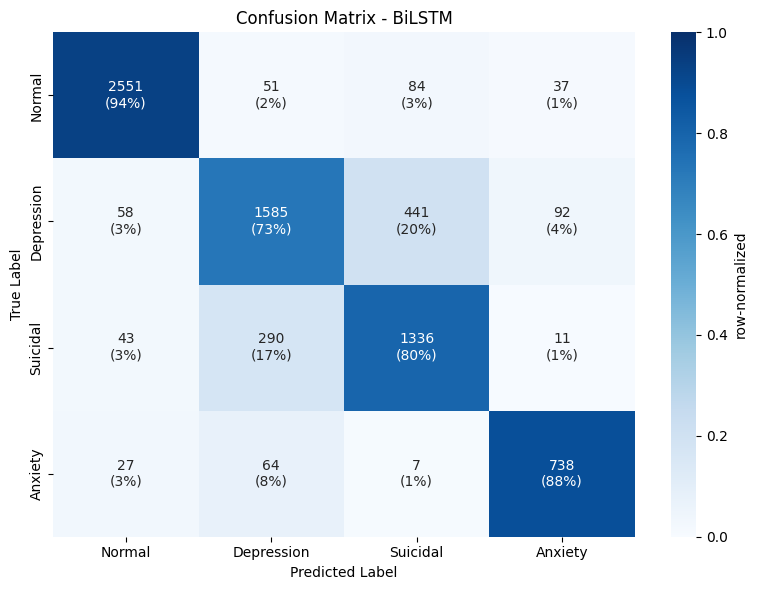

In [5]:
# 6. Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_bilstm, labels=list(range(len(class_names))))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = cm.astype(float) / np.maximum(row_sum, 1)
annot = np.array([
    [f"{cm[i, j]}\n({cm_norm[i, j]:.0%})" for j in range(len(class_names))]
    for i in range(len(class_names))
])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'row-normalized'},
)

plt.title('Confusion Matrix - BiLSTM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()